In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [2]:
# 1. Load Data (Standardized to 128x128)
IMAGE_SIZE = (64,64)
BATCH_SIZE = 32

In [3]:
train_data = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\amanp\OneDrive\Desktop\DeepFake Detection\train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_data = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\amanp\OneDrive\Desktop\DeepFake Detection\test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.


In [4]:
# 2. Setup Pretrained Base
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(64,64, 3),
    include_top=False,
    weights='imagenet'
)

C:\Users\amanp\AppData\Local\Temp\ipykernel_17916\351284234.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [5]:
base_model.trainable = False  # Freeze it so CPU training stays fast

In [6]:
# 3. Building  the actual Transfer Learning Model
model = models.Sequential([
    layers.Input(shape=(64,64, 3)),
    layers.Rescaling(1./255),      
    
    base_model,                    
    
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [7]:
# 4. Compiling the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
# 5. Train the Model
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 231s 73ms/step - accuracy: 0.8184 - loss: 0.3977 - val_accuracy: 0.8407 - val_loss: 0.3602
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 392s 126ms/step - accuracy: 0.8554 - loss: 0.3296 - val_accuracy: 0.8420 - val_loss: 0.3561
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 422s 135ms/step - accuracy: 0.8729 - loss: 0.2951 - val_accuracy: 0.8454 - val_loss: 0.3533
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 439s 141ms/step - accuracy: 0.8870 - loss: 0.2690 - val_accuracy: 0.8454 - val_loss: 0.3630
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 405s 130ms/step - accuracy: 0.8963 - loss: 0.2470 - val_accuracy: 0.8429 - val_loss: 0.3796


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


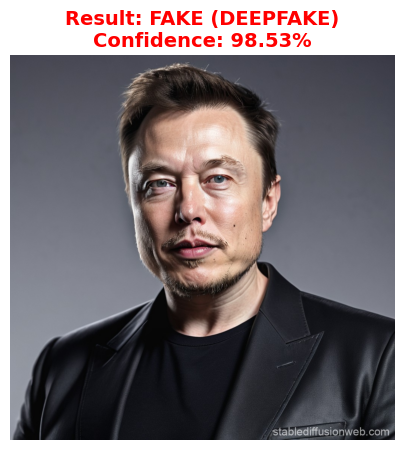

In [14]:
# 6. Optimized Prediction Function
def predict_local_image(image_path, trained_model):

    if not os.path.exists(image_path):
        print(f"Error: Could not find the file '{image_path}'. Check your extension (e.g., OIP.jpg, OIP.png)")
        return

    img_display = tf.keras.utils.load_img(image_path)
    

    img_target = tf.keras.utils.load_img(image_path, target_size=(64,64))
    img_array = tf.keras.utils.img_to_array(img_target)
    img_batch = np.expand_dims(img_array, axis=0)  

    prediction_score = trained_model.predict(img_batch)[0][0]
    
    # Determine the binary verdict
    if prediction_score >= 0.5:
        verdict = "REAL"
        confidence = prediction_score * 100
        text_color = "green"
    else:
        verdict = "FAKE (DEEPFAKE)"
        confidence = (1 - prediction_score) * 100
        text_color = "red"
        
    # Plot the result
    plt.figure(figsize=(5, 5))
    plt.imshow(img_display)
    plt.title(f"Result: {verdict}\nConfidence: {confidence:.2f}%", 
              color=text_color, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

predict_local_image("op.jpg", model)

In [15]:
model.save("deepfake_detector_model.h5")
print("Model saved successfully as deepfake_detector_model.h5")

Model saved successfully as deepfake_detector_model.h5
